# Project: Analyzing Ranking Failures and Visibility in Learning-to-Rank Systems



# Phase 1

# FOLD 1- Data Loading and Sanity Checks

#### First, we are loading and validating Fold1 training data

In [4]:
import pandas as pd
import numpy as np
from collections import defaultdict
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

#Setting display options
pd.set_option('display.max_columns', None)      #Telling pandas that when i show columns, don't truncate. Show all
sns.set_style('whitegrid')                      #Setting a global plotting style

#Paths
#Project root
PROJECT_ROOT=Path.cwd().parent
DATA_RAW=PROJECT_ROOT/'data'/'raw'
DATA_PROCESSED=PROJECT_ROOT/'data'/'processed'

print(f'Project root: {PROJECT_ROOT}')
print(f"Raw data directory: {DATA_RAW}")
print(f"Processed data directory: {DATA_PROCESSED}")

Project root: b:\Arlington\Arlington\4th_sem\Capstone\Capstone_coding
Raw data directory: b:\Arlington\Arlington\4th_sem\Capstone\Capstone_coding\data\raw
Processed data directory: b:\Arlington\Arlington\4th_sem\Capstone\Capstone_coding\data\processed


# 1. Parsing LETOR Format

In [5]:
def parse_letor_file(filepath):
    """
    Returns list of dict. 
    Each dict contains: label, qid, features (dict), docid
    """
    data=[]

    with open(filepath, 'r') as f:
        for line_num, line in enumerate(f,1):       #Starting form 1 instead of 0 just to make it easier
            line=line.strip()
            if not line:
                continue
            try:
                parts=line.split('#')   #Splitting comment (docid) from features. Everything before '#' contains label, qid, features. After that, it's metadata
                feature_part=parts[0].strip()   
                
            

                #Extracting docid if present
                docid=None
                if len(parts)>1:
                    comment=parts[1].strip()
                    if 'docid' in comment:
                        docid=comment.split('=')[1].strip() #'GX000-24-12345689 inc'
                        """
                        After #, there are docid, inc and prob. Inc is the inclusion value/importance/confidenxe from how
                        the dataset was constructed. Prob is a probability score from an older probabilistic model.
                        We will not be using them in this project. 
                        """
                        #We will now remove that trailing inc from docid
                        docid=docid.split()[0]  #'GX000-24-12345689'

                #Parsing feature part
                tokens=feature_part.split() #Breaks into a list like token[0]='1', tokens[1]='qid:10'...

                #Extracting label
                label=int(tokens[0])

                #Extracting qid
                qid_str=tokens[1]               #Takes 'qid:10'
                qid=int(qid_str.split(':')[1])  #Splits by : -> ['qid','10'] and converts '10' to 10

                #Extracting features
                features={}
                for token in tokens[2:]:        #iterates from token 2 (1:0.03, 2:0.66,...)
                    fid, value=token.split(':')     #Splits each 'fid:value'
                    features[int(fid)]=float(value) #stores into dict: {fid:value}

                data.append({ 'label': label, 
                             'qid':qid,
                             'features':features,
                             'docid':docid})
                
            except Exception as e:
                print(f'Error parsing line {line_num}: {e}')
                print(f'Line content: {line[:100]}...') #prints the first 100 characters of the offending line
                continue

    return data

# 2. Loading Fold1 Training data

In [7]:
#path to the fold1 training data
FOLD1_DIR=DATA_RAW/'MQ2007'/'Fold1'
TRAIN_FILE=FOLD1_DIR/'train.txt'

print(f'Looking for training file at: {TRAIN_FILE}')
print(f'File exists: {TRAIN_FILE.exists()}')

if not TRAIN_FILE.exists():
    print("\n File not found. Please check")

else:
    print("\n Loading Fold1 training data...")
    train_data=parse_letor_file(str(TRAIN_FILE))
    print(f'Loaded {len(train_data)} documents')

Looking for training file at: b:\Arlington\Arlington\4th_sem\Capstone\Capstone_coding\data\raw\MQ2007\Fold1\train.txt
File exists: True

 Loading Fold1 training data...
Loaded 42158 documents


# 3. Converting to dataframe for analysis

In [ ]:
#Creating a structured DAtaFrame
records=[]
for item in train_data:
    record={
        'label':item['label'],
        'qid':item['qid'],
        'docid':item['docid']
    }       
    #Just getting the identifiers not features

    #Adding all features as columns
    for fid, value in item['features'].items():    
        record[f'f{fid}']=value     #take the value of fid, convert it to a string and insert it into 'f{}'
        """
        If item['features'] is: {1:0.03, 2:0.66, 3:0.5, ..., 46:0.0},
        then this loop creates columns like: f1  f2  f3  ...  f46 with their numeric values 
        """
    records.append(record)  #Adds one fully flattened row

df=pd.DataFrame(records)
print(f"Dataframe shape: {df.shape}")
print(f"\n First few rows:")
df.head()

Dataframe shape: (42158, 49)

 First few rows:


,label,qid,docid,f1,f2,f3,f4,f5,f6,f7,f8,f9,f10,f11,f12,f13,f14,f15,f16,f17,f18,f19,f20,f21,f22,f23,f24,f25,f26,f27,f28,f29,f30,f31,f32,f33,f34,f35,f36,f37,f38,f39,f40,f41,f42,f43,f44,f45,f46
0,0,10,GX000-00-0000000,0.000000,0.000000,0.00,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.001348,0.0000,0.222222,0.000000,0.001282,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.017241,0.000000,0.000000,0.0
1,1,10,GX000-24-12369390,0.031310,0.666667,0.50,0.166667,0.033206,0.0,0.0,0.0,0.0,0.0,0.023327,0.641157,0.498951,0.323153,0.026674,0.029246,0.5000,0.222222,0.111111,0.029398,0.689128,0.636228,0.869764,0.716400,0.725186,0.554961,0.695985,0.504060,0.602946,0.679534,0.730286,0.687414,0.529688,0.436996,0.643739,0.372337,0.646890,0.686107,0.823908,0.750092,0.385426,0.923077,0.086207,0.333333,0.448276,0.0
2,1,10,GX000-62-7863450,0.078682,0.166667,0.50,0.333333,0.080022,0.0,0.0,0.0,0.0,0.0,0.108216,0.174635,0.501049,0.351114,0.112102,0.118642,0.5625,0.944444,0.333333,0.119184,0.696967,0.486387,0.938768,0.577082,0.209891,0.160965,0.185260,0.128353,0.205904,0.213219,0.256479,0.156858,0.352022,0.131372,0.079660,0.068825,0.649824,0.578581,0.868557,0.641385,0.010462,0.076923,0.074713,0.833333,0.678161,0.0
3,1,10,GX016-48-5543459,0.019058,1.000000,1.00,0.500000,0.022591,0.0,0.0,0.0,0.0,0.0,0.021256,1.000000,1.000000,0.674267,0.028989,0.020426,0.8750,0.777778,0.388889,0.021043,0.949146,0.867628,1.000000,0.838125,0.776131,1.000000,1.000000,1.000000,0.505564,0.922004,1.000000,1.000000,0.769817,0.890277,0.896671,0.940500,0.918403,0.868457,1.000000,0.863460,0.016642,0.153846,0.040230,0.833333,0.896552,0.0
4,0,10,GX037-87-3082362,0.039477,0.000000,0.75,0.166667,0.040555,0.0,0.0,0.0,0.0,0.0,0.036178,0.000000,0.751573,0.175557,0.039086,0.053319,0.1875,1.000000,0.111111,0.053668,0.605907,0.469614,0.827181,0.582661,0.000000,0.000000,0.000000,0.000000,0.266984,0.204123,0.323377,0.176450,0.287760,0.074987,0.002373,0.052280,0.565875,0.569440,0.769845,0.646567,0.073711,0.076923,0.034483,0.333333,0.218391,0.0


# 4. Basic Sanity Checks

In [9]:
print("="*60)
print("SANITY CHECK SUMMARY")
print("="*60)

#Check 1: Total documents and queries
total_docs=len(df)
unique_queries=df['qid'].nunique()
print(f"\n 1. DATASET SIZE")
print(f"\n Total documents: {total_docs:,}")
print(f"\n Unique queries: {unique_queries:,}")
print(f"\n Avg docs per query: {total_docs/unique_queries:.2f}")


#Check 2: Label distribution
print(f"\n \n 2. LABEL DISTRIBUTION")
label_counts=df['label'].value_counts().sort_index()
for label, count in label_counts.items():
    pct=100*count/total_docs
    print(f"\n Label {label}: {count:,} ({pct:.2f}%)")


#Check 3: Feature completeness
feature_cols=[col for col in df.columns if col.startswith('f')]
num_features=len(feature_cols)
print("\n 3. FEATURES")
print(f"\n Number of features: {num_features}")
print(f"\n Feature range: f1 to f{num_features}")


#Checking for missing values in features
missing_counts=df[feature_cols].isnull().sum()
if missing_counts.sum()>0:
    print(f"Missing values detected")
    print(missing_counts[missing_counts>0])
else:
    print(f"No missing feature values")


#Check 4: DocID Completeness
print(f"\n DOCUMENT COMPLETENESS")
docs_with_id=df['docid'].notna().sum()
print(f"\n Documents with docid: {docs_with_id:,} ({100*docs_with_id/total_docs:.2f}%)")
if docs_with_id < total_docs:
    print(f"{total_docs-docs_with_id} documents missing docid")

SANITY CHECK SUMMARY

 1. DATASET SIZE

 Total documents: 42,158

 Unique queries: 1,017

 Avg docs per query: 41.45

 
 2. LABEL DISTRIBUTION

 Label 0: 31,585 (74.92%)

 Label 1: 8,388 (19.90%)

 Label 2: 2,185 (5.18%)

 3. FEATURES

 Number of features: 46

 Feature range: f1 to f46
No missing feature values

 DOCUMENT COMPLETENESS

 Documents with docid: 42,158 (100.00%)


# 5. Per-Query Sanity Checks

In [ ]:
print("\n"+"="*60)
print("PER-QUERY ANALYSIS")
print("="*60)

#Grouping by query
query_stats=[]
for qid, group in df.groupby('qid'):    
    #Key idea in learning-to-rank: A sample is not a single row. 
    #A sample is a query, which has many documents.
    #For each qid, group is a mini-table containing all documents for that query.
    stats={
        'qid':qid,
        'num_docs':len(group),
        'num_relevant':(group['label']>0).sum(),
        'num_highly_relevant':(group['label']>=2).sum(),
        'max_label':group['label'].max(),
        'min_label':group['label'].min(),
        'unique_labels':group['label'].nunique()
    }
    query_stats.append(stats)

query_df=pd.DataFrame(query_stats)
#query_df has one row per query (1017 rows)

print(f"\n 5. QUERY STATISTICS")
print(f" Docs per query - Min: {query_df['num_docs'].min()}")
print(f" Docs per query - Max: {query_df['num_docs'].max()}")
print(f" Docs per query - Mean: {query_df['num_docs'].mean():.2f}")
print(f" Docs per query - Median: {query_df['num_docs'].median():.0f}")

print(f"\n 6. RELEVANCE PER QUERY")
print(f" Avg relevant docs per query: {query_df['num_relevant'].mean():.2f}")
print(f" Avg highly relevant (label>=2 per query: {query_df['num_highly_relevant'].mean():.2f})")

#Checking for queries with no relevant docs
queries_no_relevant=(query_df['num_relevant']==0).sum()
if queries_no_relevant>0:
    print(f" {queries_no_relevant} queries have NO relevant documents")
else:
    print(f" All queries have at least one relevant document")

print(f"\n 7. LABEL DIVERSITY")
print(f" Avg unique labels per query: {query_df['unique_labels'].mean():.2f}")
print(f" Queries with only one label: {(query_df['unique_labels']==1).sum()}")


PER-QUERY ANALYSIS

 5. QUERY STATISTICS
 Docs per query - Min: 6
 Docs per query - Max: 147
 Docs per query - Mean: 41.45
 Docs per query - Median: 40

 6. RELEVANCE PER QUERY
 Avg relevant docs per query: 10.40
 Avg highly relevant (label>=2 per query: 2.15)
 147 queries have NO relevant documents

 7. LABEL DIVERSITY
 Avg unique labels per query: 2.21
 Queries with only one label: 148


Brief interpretation:
 5. QUERY STATISTICS
 Docs per query - Min: 6
 Docs per query - Max: 147
 Docs per query - Mean: 41.45
 Docs per query - Median: 40

 Queries are fairly consistent. Mean is nearly same as median. Some queries are small and some are very large. Larger queries leave us some more room for ranking errors.

 6. RELEVANCE PER QUERY
 Avg relevant docs per query: 10.40
 Avg highly relevant (label>=2 per query: 2.15)

 This shows there are many irrelevant docs competing and the best docs are rare. We will have materials for this ranking failure analysis project.




# 6. Visualizations

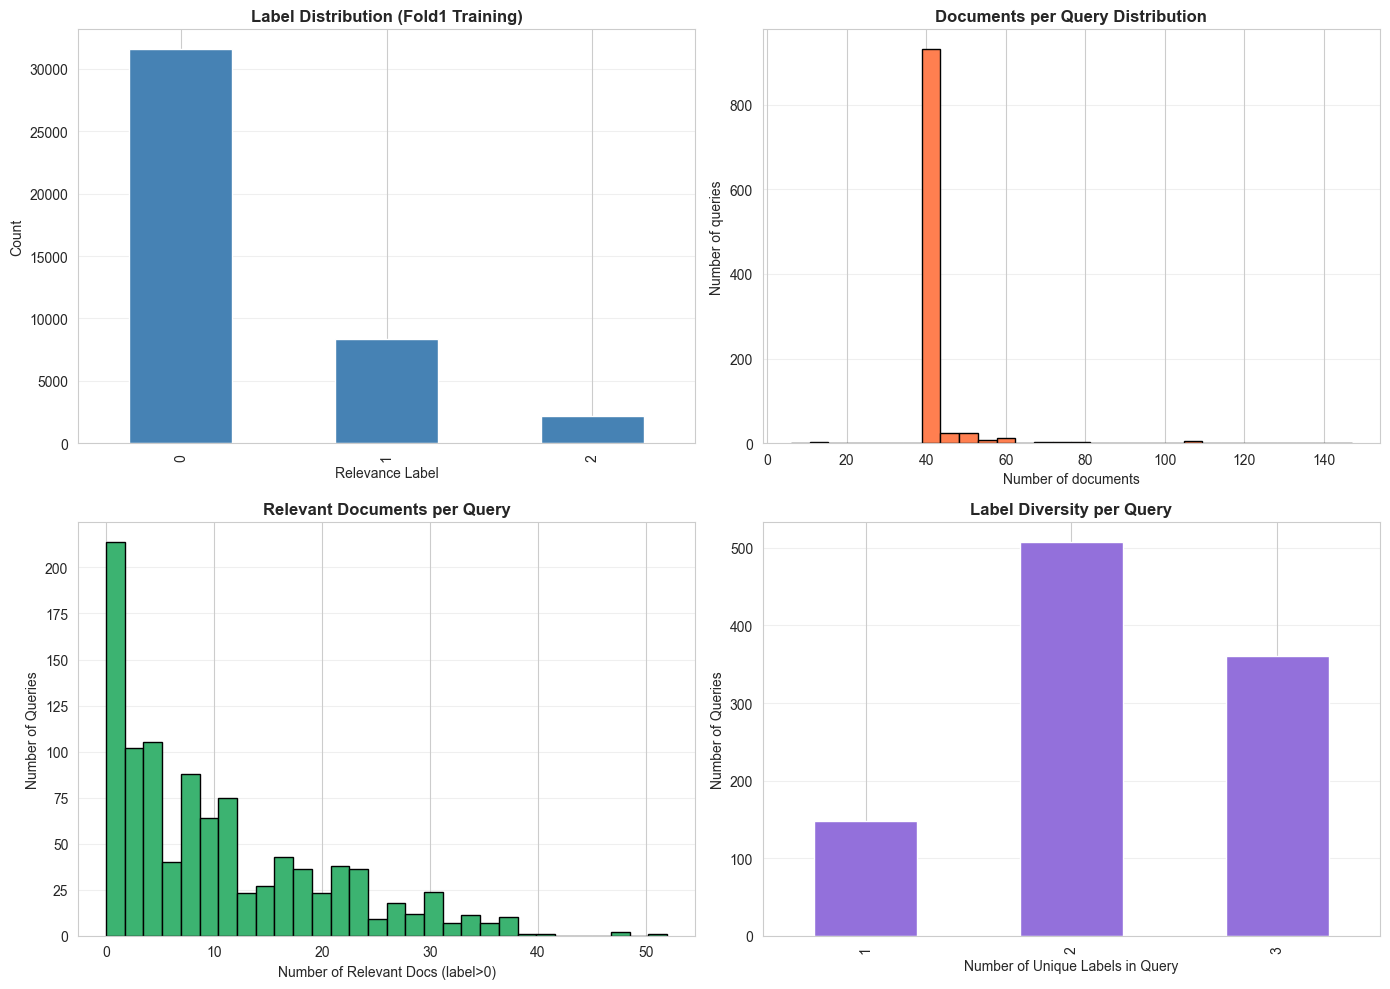

In [13]:
fig, axes= plt.subplots(2,2, figsize=(14,10))

#Plot 1: Label distribution
label_counts.plot(kind='bar', ax=axes[0,0], color='steelblue')
axes[0,0].set_title('Label Distribution (Fold1 Training)', fontsize=12, fontweight='bold')
axes[0,0].set_xlabel('Relevance Label')
axes[0,0].set_ylabel('Count')
axes[0,0].grid(axis='y', alpha=0.3)

#Plot 2: Documents per query distribution
axes[0,1].hist(query_df['num_docs'], bins=30, color='coral', edgecolor='black')
axes[0,1].set_title('Documents per Query Distribution', fontsize=12, fontweight='bold')
axes[0,1].set_xlabel('Number of documents')
axes[0,1].set_ylabel('Number of queries')
axes[0,1].grid(axis='y', alpha=0.3)

#Plot 3: Relevant documents per query
axes[1,0].hist(query_df['num_relevant'], bins=30, color='mediumseagreen', edgecolor='black')
axes[1,0].set_title('Relevant Documents per Query', fontsize=12, fontweight='bold')
axes[1,0].set_xlabel('Number of Relevant Docs (label>0)')
axes[1,0].set_ylabel('Number of Queries')
axes[1,0].grid(axis='y', alpha=0.3)

#Plot 4: Label diversity per query
query_df['unique_labels'].value_counts().sort_index().plot(kind='bar', ax=axes[1,1], color='mediumpurple')
axes[1,1].set_title('Label Diversity per Query', fontsize=12, fontweight='bold')
axes[1,1].set_xlabel('Number of Unique Labels in Query')
axes[1,1].set_ylabel('Number of Queries')
axes[1,1].grid(axis='y',alpha=0.3)

plt.tight_layout()
plt.show()

# 6a. Few more visualizations

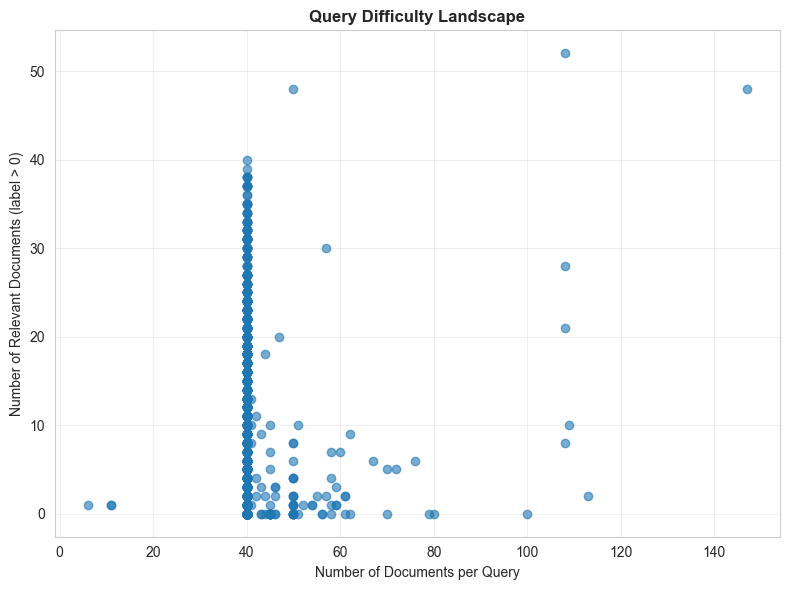

In [15]:
plt.figure(figsize=(8,6))
plt.scatter(
    query_df['num_docs'],
    query_df['num_relevant'],
    alpha=0.6
)

plt.xlabel('Number of Documents per Query')
plt.ylabel('Number of Relevant Documents (label > 0)')
plt.title('Query Difficulty Landscape', fontweight='bold')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

For each query, how many candidate documents exist, and how many of them are actually relevant?

Very strong vertical line around 40 documents. Many queries have roughly the same number of candidate documents. This matches the earlier stats (mean close to 41 and median=40). There are also many points close to y=0,1,2.

There are a few extreme outliers.

This scatterplot shows query difficulty by jointly visualizing candidate set size and relevance density. Many queries contain a large number of candidate documents but only a small number of relevant results.

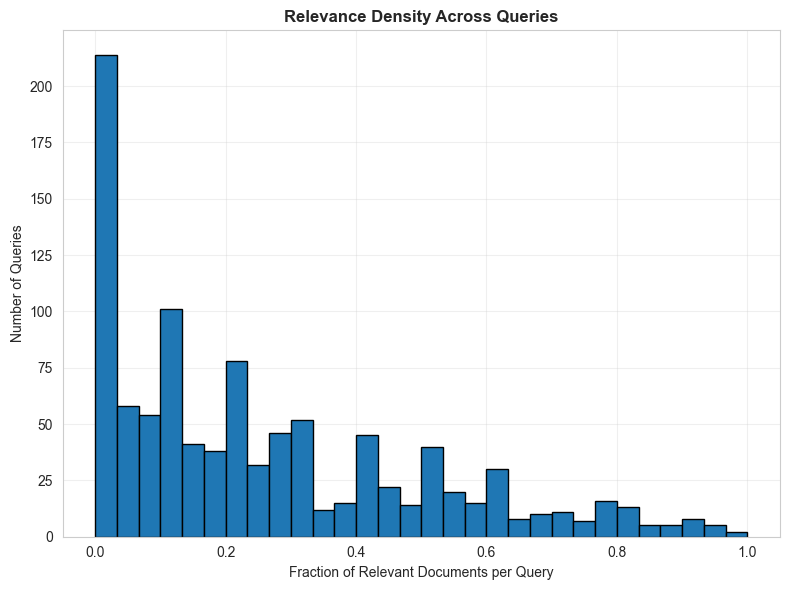

In [16]:
query_df['relevance_ratio'] = query_df['num_relevant'] / query_df['num_docs']

plt.figure(figsize=(8,6))
plt.hist(query_df['relevance_ratio'], bins=30, edgecolor='black')
plt.xlabel('Fraction of Relevant Documents per Query')
plt.ylabel('Number of Queries')
plt.title('Relevance Density Across Queries', fontweight='bold')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


For a typical query, what fraction of its documents actually matter?

We can see most bars are clustered near 0-0.2. This means most queries have very low relevance density. Some have almost none. Ranking is mostly about finding needles in haystacks and **precision at the top ranks matters much more than recall.**

**As we have very few relevant documents, putting those on the top (1-2 positions) should take more priority than putting couple more in 6,7,8,9 positions.**

There is also a long right tail. They are the easy queries but are less informative for evaluating ranking quality.

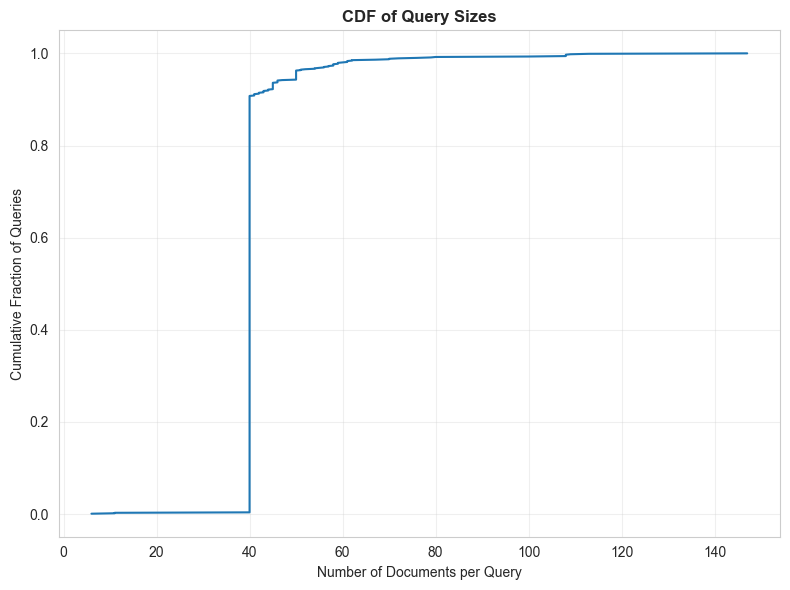

In [17]:
sorted_docs = np.sort(query_df['num_docs'])
cdf = np.arange(1, len(sorted_docs)+1) / len(sorted_docs)

plt.figure(figsize=(8,6))
plt.plot(sorted_docs, cdf)
plt.xlabel('Number of Documents per Query')
plt.ylabel('Cumulative Fraction of Queries')
plt.title('CDF of Query Sizes', fontweight='bold')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


What percentage of queries have at most X documents?

Again, sharp jump at around 40 documents. After 50 documents, the curve flattens and only a small fraction of queries are very large. Very large queries are rare but exist. We can easily see that about 90% of queries have fewer than 42 documents. Only a small fraction of queries exceed 100 candidates.

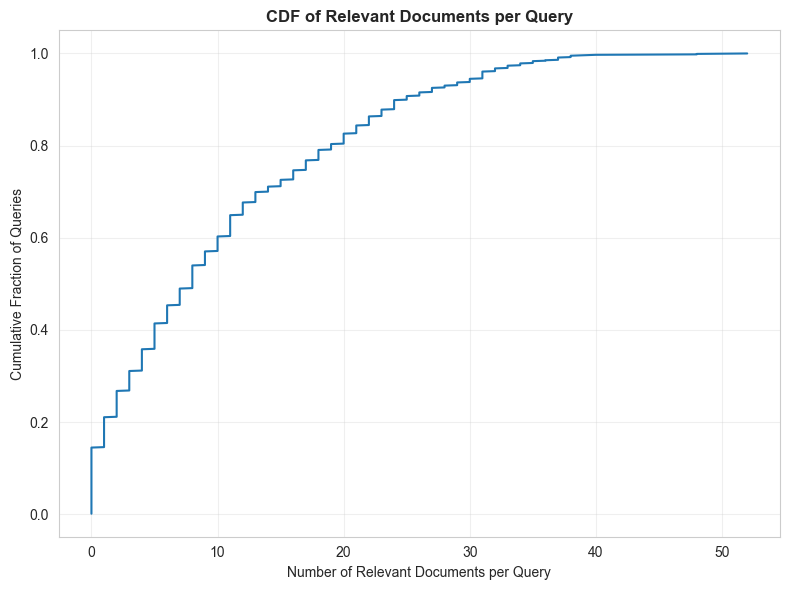

In [18]:
sorted_rel = np.sort(query_df['num_relevant'])
cdf = np.arange(1, len(sorted_rel)+1) / len(sorted_rel)

plt.figure(figsize=(8,6))
plt.plot(sorted_rel, cdf)
plt.xlabel('Number of Relevant Documents per Query')
plt.ylabel('Cumulative Fraction of Queries')
plt.title('CDF of Relevant Documents per Query', fontweight='bold')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


For how many queries is the number of relevant documents small?

There is a steep rise near small values. This means a large fraction of queries have 0-5 relevant documents. And very few have more than 20. Long right tail means some queries have 30-50 relevant documents but they are rare and don't dominate our evaluation.

C:\Users\kusha\AppData\Local\Temp\ipykernel_43456\3418627166.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_with_bins['label'].groupby(df_with_bins['size_bin']).value_counts(normalize=True).unstack().plot(


<Figure size 800x600 with 0 Axes>

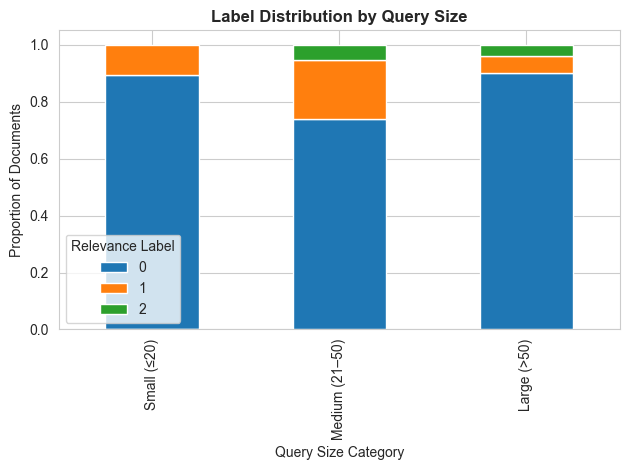

In [19]:
# Bin queries by size
bins = [0, 20, 50, np.inf]
labels = ['Small (≤20)', 'Medium (21–50)', 'Large (>50)']
query_df['size_bin'] = pd.cut(query_df['num_docs'], bins=bins, labels=labels)

# Merge bin info back to document-level data
df_with_bins = df.merge(query_df[['qid', 'size_bin']], on='qid')

plt.figure(figsize=(8,6))
df_with_bins['label'].groupby(df_with_bins['size_bin']).value_counts(normalize=True).unstack().plot(
    kind='bar', stacked=True
)
plt.xlabel('Query Size Category')
plt.ylabel('Proportion of Documents')
plt.title('Label Distribution by Query Size', fontweight='bold')
plt.legend(title='Relevance Label')
plt.tight_layout()
plt.show()


Does query size affect how relevance is distributed?

This shows small queries are often low signal. Sometimes there are no relevant docs at all and ranking is very sensitive.

Meanwhile medium-sized and large queries have more relevant documents. Large queries can be very noisy and a few relevant docs may be buried deep. 
Medium-sized queries carry the strongest learning signal as per this stacked chart.

# 7. Sample Query Inspection

In [ ]:
#Showing details for a few sample queries

print("\n"+"="*60)
print("SAMPLE QUERY INSPECTION")
print("="*60)

sample_qids=df['qid'].unique()[:3]
#Gives a list of unique of query id in the order they appear and picks the first 3

for qid in sample_qids:
    query_docs=df[df['qid']==qid]
    print(f"\nQuery ID: {qid}")
    print(f" Total documents: {len(query_docs)}")
    print(f" Label distribution: {query_docs['label'].value_counts().sort_index().to_dict()}")
    print(f" Sample documents:")
    display(query_docs[['qid','docid','label','f1','f2','f3']].head(5))


SAMPLE QUERY INSPECTION

Query ID: 10
 Total documents: 40
 Label distribution: {0: 24, 1: 16}
 Sample documents:


,qid,docid,label,f1,f2,f3
0,10,GX000-00-0000000,0,0.000000,0.000000,0.00
1,10,GX000-24-12369390,1,0.031310,0.666667,0.50
2,10,GX000-62-7863450,1,0.078682,0.166667,0.50
3,10,GX016-48-5543459,1,0.019058,1.000000,1.00
4,10,GX037-87-3082362,0,0.039477,0.000000,0.75



Query ID: 15
 Total documents: 40
 Label distribution: {0: 29, 1: 8, 2: 3}
 Sample documents:


,qid,docid,label,f1,f2,f3
40,15,GX000-63-11995977,1,0.172753,0.00,0.00
41,15,GX001-21-11212159,0,0.006565,0.75,0.75
42,15,GX002-50-7293787,0,0.027493,1.00,1.00
43,15,GX003-47-3035937,1,0.031186,0.00,0.50
44,15,GX004-95-1230642,1,0.171522,0.00,0.00



Query ID: 33
 Total documents: 40
 Label distribution: {0: 39, 2: 1}
 Sample documents:


,qid,docid,label,f1,f2,f3
80,33,GX000-79-1969938,0,0.07500,0.142857,0.5
81,33,GX001-57-11634684,0,0.06875,0.571429,0.5
82,33,GX003-21-16226598,0,0.10000,0.000000,0.0
83,33,GX003-89-5527967,0,0.01250,0.000000,0.5
84,33,GX007-11-15268600,2,0.08750,0.142857,0.5


Query with the qid 15 is the best among these three as it contains documents of all relevance and it will be easier to distinguish. We want label 2 docs at the very top, then label 1 and then label 0. 

On the other hand, there is only one relevant document, which is highly relevant. This is the perfect example for finding needle in a haystack situation. If that relevant document is placed very high at the top, then great, otherwise it could count as failure.

# 8. Feature Statistics

In [21]:
#Checking for zero-variance features or suspicious patterns
print("\n"+"="*60)
print("FEATURE STATISTICS")
print("="*60)

feature_stats=df[feature_cols].describe().T
print("\n Feature Summary (first 10 features):")
display(feature_stats.head(10))

#Checking for zero-variance features
zero_var_features=feature_stats[feature_stats['std']==0].index.tolist()
if zero_var_features:
    print(f"\n Zero-variance features detected: {zero_var_features}")
else:
    print("\n All features have non-zero variance")

#Checking for features with extreme values
print("\n Feature value ranges (checking for anomalies):")
for col in feature_cols[:5]:
    print(f"{col}: [{df[col].min():.4f},{df[col].max():.4f}]")


FEATURE STATISTICS

 Feature Summary (first 10 features):


,count,mean,std,min,25%,50%,75%,max
f1,42158.0,0.163040,0.236600,0.0,0.018692,0.062500,0.192000,1.0
f2,42158.0,0.137577,0.249490,0.0,0.000000,0.000000,0.200000,1.0
f3,42158.0,0.252003,0.341061,0.0,0.000000,0.000000,0.500000,1.0
f4,42158.0,0.142365,0.308510,0.0,0.000000,0.000000,0.000000,1.0
f5,42158.0,0.166726,0.236586,0.0,0.021404,0.067277,0.198875,1.0
f6,42158.0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.0
f7,42158.0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.0
f8,42158.0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.0
f9,42158.0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.0
f10,42158.0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.0



 Zero-variance features detected: ['f6', 'f7', 'f8', 'f9', 'f10']

 Feature value ranges (checking for anomalies):
f1: [0.0000,1.0000]
f2: [0.0000,1.0000]
f3: [0.0000,1.0000]
f4: [0.0000,1.0000]
f5: [0.0000,1.0000]


f6 to f10 are detected to have zero variance. They are not very useful as machine learning models learn from differences. These features values never change and contain zero information.

# 9. Final Validation Summary

In [24]:
print("\n"+"="*60)
print("VALIDATION SUMMARY")
print("="*60)

validation_checks=[
    ("Data loaded successfully", len(df)>0),
    ("All queries have documents", unique_queries>0),
    ("Labels are valid (0-2)", df['label'].isin([0,1,2]).all()),
    ("No missing feature values", df[feature_cols].isnull().sum().sum()==0),
    ("All queries have at least one document", query_df['num_docs'].min()>0),
    
]

print("\nValidation Checks:")
for check_name, passed in validation_checks:
    status="PASS" if passed else "FAIL"
    print(f"{status}: {check_name}")

all_passed=all(check[1] for check in validation_checks)
if all_passed:
    print("\n"+"="*60)
    print("All SANITY CHECKS PASSED")
    print("="*60)

else:
    print("\n"+"="*60)
    print("SOME CHECKS FAILED - PLEASE INVESTIGATE")
    print("="*60)


VALIDATION SUMMARY

Validation Checks:
PASS: Data loaded successfully
PASS: All queries have documents
PASS: Labels are valid (0-2)
PASS: No missing feature values
PASS: All queries have at least one document

All SANITY CHECKS PASSED


# 10. Saving Processed Data

In [25]:
#Saving processed data for later use

if all_passed:
    #Creating processed directory if it doesn't exist
    DATA_PROCESSED.mkdir(parents=True, exist_ok=True)

    #Saving main dataframe
    output_file=DATA_PROCESSED/'fold1_train_processed.csv'
    df.to_csv(output_file, index=False)
    print(f"Saved processed training data to: {output_file}")
    print(f"Shape: {df.shape}")

    #Saving query-level statistics
    query_stats_file=DATA_PROCESSED/'fold1_train_query_stats.csv'
    query_df.to_csv(query_stats_file, index=False)
    print(f"Saved query statistics to: {query_stats_file}")
    print(f"Shape: {query_df.shape}")

    #Saving summary statistics
    summary={
        'total_documents':total_docs,
        'unique_queries':unique_queries,
        'num_features':num_features,
        'label_distribution':label_counts.to_dict(),
        'avg_docs_per_query':float(total_docs/unique_queries),
        'avg_relevant_per_query':float(query_df['num_relevant'].mean())
    }

    summary_file=DATA_PROCESSED/'fold1_train_summary.txt'
    with open(summary_file, 'w') as f:
        f.write('Fold1 Training Data Summary\n')
        f.write("="*50+"\n\n")
        for key, value in summary.items():
            f.write(f"{key}:{value}\n")
    print(f"Saved summary to: {summary_file}")

    print("\n"+"="*60)
    print("All processed data saved successfully")
    print("="*60)

else:
    print("Skipping save- some validation checks failed")

Saved processed training data to: b:\Arlington\Arlington\4th_sem\Capstone\Capstone_coding\data\processed\fold1_train_processed.csv
Shape: (42158, 49)
Saved query statistics to: b:\Arlington\Arlington\4th_sem\Capstone\Capstone_coding\data\processed\fold1_train_query_stats.csv
Shape: (1017, 9)
Saved summary to: b:\Arlington\Arlington\4th_sem\Capstone\Capstone_coding\data\processed\fold1_train_summary.txt

All processed data saved successfully


**We have a few zero-variance features. We will take care of them as we move forward.**